<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
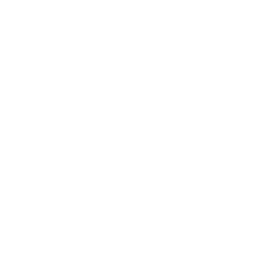
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ανίχνευση Φθοράς Βιομηχανικών Ρουλεμάν</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Μηχανική Αξιοπιστίας &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Περίληψη

Ένας στόλος 100 βιομηχανικών ρουλεμάν παρακολουθείται με σταθερό πρόγραμμα συντήρησης. Η φθορά πέραν του ορίου ανοχής είναι ανιχνεύσιμη μόνο στις προγραμματισμένες διακοπές λειτουργίας, άρα ο χρόνος έως τη φθορά δεν παρατηρείται ποτέ με ακρίβεια &mdash; είναι **μεσοδιαστηματικά λογοκριμένος** (interval-censored) μεταξύ της τελευταίας επιθεώρησης που πέρασε (`last_ok_hours`) και της πρώτης επιθεώρησης που απέτυχε (`first_worn_hours`). Τα ρουλεμάν που παραμένουν εντός ανοχής στην τελευταία τους επιθεώρηση είναι δεξιά λογοκριμένα (right-censored).

Η PROC ICLIFETEST προσαρμόζει τον μη παραμετρικό εκτιμητή Turnbull της συνάρτησης επιβίωσης χωρίς φθορά και συγκρίνει δύο καθεστώτα λίπανσης (Συνθετικό έναντι Ορυκτέλαιου). Η ανάλυση απαντά σε ένα συγκεκριμένο ερώτημα συντήρησης: **παρατείνει ουσιαστικά το συνθετικό λιπαντικό τη διάρκεια ζωής χωρίς φθορά ενός ρουλεμάν;** Κάθε αριθμός που αναφέρεται παρακάτω διαβάζεται απευθείας από την εκτελεσμένη έξοδο της διαδικασίας.


## Πηγή Δεδομένων

| Σύνολο Δεδομένων | Ν | Περιγραφή |
|---------|---|-------------|
| `bearing_inspections` | 100 | Μία γραμμή ανά ρουλεμάν: λιπαντικό, φορτίο, ταχύτητα περιστροφής, και το διάστημα επιθεώρησης που πλαισιώνει την έναρξη της φθοράς |

Η μεσοδιαστηματικά λογοκριμένη απόκριση είναι το ζεύγος `(last_ok_hours, first_worn_hours)`. Μια απούσα τιμή `first_worn_hours` σηματοδοτεί ένα ρουλεμάν που παρέμεινε εντός ανοχής στην τελευταία του επιθεώρηση (δεξιά λογοκριμένο).


---

In [1]:
/* Δεδομένα επιθεώρησης φθοράς ρουλεμάν: 100 ρουλεμάν, δύο καθεστώτα λίπανσης.
   Το συνθετικό λιπαντικό έχει σχεδιαστεί ώστε να παρατείνει τη διάρκεια ζωής χωρίς φθορά,
   έτσι ώστε οι καμπύλες επιβίωσης να διαχωρίζονται προς μια φυσικά εύλογη κατεύθυνση. */
ΔΕΔΟΜΕΝΑ bearing_inspections;
    CALL streaminit(42);
    LENGTH lubricant $20;
    ΕΠΑΝΑΛΗΨΗ bearing_id = 1 ΕΩΣ 100;
        ΕΑΝ rand('uniform') * 2 <= 1 ΤΟΤΕ lubricant = 'Συνθετικό'; ΑΛΛΙΩΣ lubricant = 'Ορυκτέλαιο';
        load_kn   = round(10 + rand('exponential') * 15, 0.1);
        rpm       = round(1000 + rand('uniform') * 4000, 0);
        /* Το συνθετικό στρώμα καθυστερεί την έναρξη μετρήσιμης φθοράς */
        ΕΑΝ lubricant = 'Συνθετικό' ΤΟΤΕ BASE = 2600; ΑΛΛΙΩΣ BASE = 1500;
        last_ok_hours    = round(rand('uniform') * BASE, 0);
        first_worn_hours = last_ok_hours + round(400 + rand('exponential') * 900, 0);
        /* ~25% παραμένουν χωρίς φθορά στην τελική επιθεώρηση -> δεξιά λογοκριμένα */
        ΕΑΝ rand('uniform') > 0.75 ΤΟΤΕ first_worn_hours = .;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ i BASE;
    ΚΡΑΤΗΣΗ bearing_id lubricant load_kn rpm last_ok_hours first_worn_hours;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA bearing_inspections


NOTE: Wrote bearing_inspections (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

### Συνθήκες λειτουργίας ανά λιπαντικό

Πριν τη μοντελοποίηση της επιβίωσης, ας συνοψίσουμε το πραγματικό φορτίο εργασίας κάθε ομάδας λιπαντικού, ώστε τυχόν διαφορά στη διάρκεια ζωής χωρίς φθορά να μην οφείλεται απλώς σε σύγχυση με το φορτίο ή την ταχύτητα.


In [2]:
/* Λειτουργικό φορτίο εργασίας ανά καθεστώς λίπανσης */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=bearing_inspections n mean std MAX maxdec=1;
    ΜΕΤΑΒΛΗΤΗ load_kn rpm;
    ΚΛΑΣΗ lubricant;
    ΕΤΙΚΕΤΑ load_kn='Φορτίο (kN)' rpm='Ταχύτητα Περιστροφής (rpm)' lubricant='Λιπαντικό';
ΕΚΤΕΛΕΣΗ;


                                                  The MEANS Procedure

                                     Analysis Variable : load_kn Φορτίο (kN)

        Λιπαντικό                     N Obs           Mean        Std Dev        Maximum
        --------------------------------------------------------------------------------
        Ορυκτέλαιο                       47           21.5            9.9           51.7
        Συνθετικό                        53           25.8           14.0           64.6
        --------------------------------------------------------------------------------

                         Analysis Variable : rpm Ταχύτητα Περιστροφής (rpm)

        Λιπαντικό                     N Obs           Mean        Std Dev        Maximum
        --------------------------------------------------------------------------------
        Ορυκτέλαιο                       47         2786.0         1093.5         4988.1
        Συνθετικό                        53         2949.7   


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Παράθυρο επιθεώρησης έναντι λειτουργικού φορτίου

Κάθε σημείο αντιστοιχεί σε ένα ρουλεμάν. Η κατακόρυφη θέση είναι η τελευταία ώρα στην οποία το ρουλεμάν επιβεβαιώθηκε εντός ανοχής· το χρώμα δηλώνει το λιπαντικό του. Αυτό δείχνει το ακατέργαστο μοτίβο έκθεσης που τροφοδοτεί το μεσοδιαστηματικά λογοκριμένο μοντέλο.



NOTE: PROC SGPLOT data=bearing_inspections

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


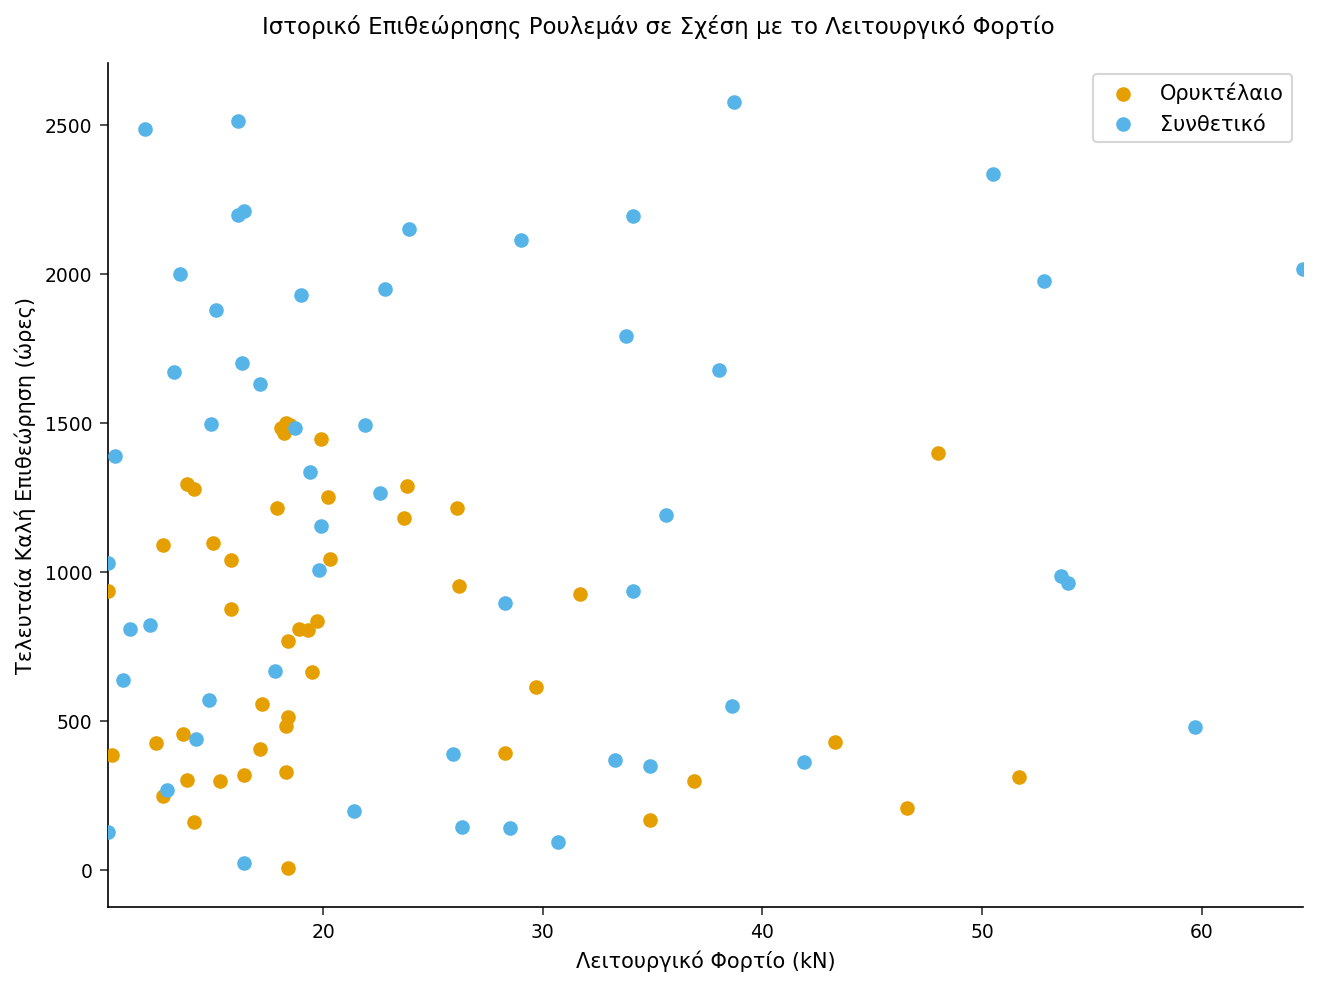

In [3]:
/* Τελευταία ώρα επιθεώρησης εντός ανοχής έναντι φορτίου, ανά λιπαντικό */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=bearing_inspections;
    SCATTER x=load_kn y=last_ok_hours / GROUP=lubricant;
    XAXIS ΕΤΙΚΕΤΑ='Λειτουργικό Φορτίο (kN)';
    YAXIS ΕΤΙΚΕΤΑ='Τελευταία Καλή Επιθεώρηση (ώρες)';
    TITLE 'Ιστορικό Επιθεώρησης Ρουλεμάν σε Σχέση με το Λειτουργικό Φορτίο';
ΕΚΤΕΛΕΣΗ;


---

### Επιβίωση με μεσοδιαστηματική λογοκρισία ανά λιπαντικό

Η PROC ICLIFETEST υπολογίζει τη μη παραμετρική εκτίμηση μέγιστης πιθανοφάνειας Turnbull της συνάρτησης επιβίωσης χωρίς φθορά για κάθε στρώμα λιπαντικού, γράφει τον πλήρη πίνακα επιβίωσης στο `surv_estimates.csv`, και σχεδιάζει το γράφημα επιβίωσης ανά στρώμα. Το στατιστικό log-rank για μεσοδιαστηματικά λογοκριμένα δεδομένα ελέγχει την ισότητα των δύο κατανομών επιβίωσης.



----------------------------------------------------------------------------------------------------------------------
                                               The ICLIFETEST Procedure                                               
----------------------------------------------------------------------------------------------------------------------
Left Bound Variable        last_ok_hours
Right Bound Variable       first_worn_hours
Stratum Variable           lubricant



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC ICLIFETEST data=bearing_inspections

NOTE: Using Python (numpy 2.4.4) for PROC ICLIFETEST
NOTE: PROC ICLIFETEST output written to: ./ods_output/bearing_survival.svg
NOTE: OUTSURV dataset written to: "./surv_estimates.csv"
NOTE: Interval-Censored Log-Rank Test: Chi-Square = 11.6806, p-value = 0.0006
NOTE: ODS Graphics is OFF.


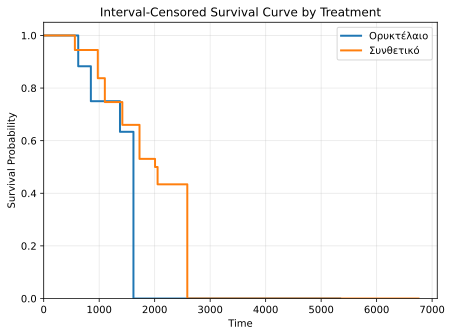

In [4]:
/* Εκτίμηση επιβίωσης Turnbull + γράφημα επιβίωσης ανά στρώμα + έλεγχος log-rank */
ODS GRAPHICS ON;
ODS GRAPHICS / IMAGENAME='bearing_survival';
ΔΙΑΔΙΚΑΣΙΑ ICLIFETEST ΔΕΔΟΜΕΝΑ=bearing_inspections
                PLOTS=SURVIVAL
                outsurv='surv_estimates.csv';
    STRATA lubricant;
    TIME (last_ok_hours, first_worn_hours);
ΕΚΤΕΛΕΣΗ;
ODS GRAPHICS OFF;


---

### Ευρήματα

Όλοι οι αριθμοί παρακάτω διαβάζονται απευθείας από τον εκτελεσμένο πίνακα PROC MEANS, τις
εκτιμήσεις επιβίωσης Turnbull στο `surv_estimates.csv`, και το log της διαδικασίας.

- **Δείγμα.** Από τα 100 ρουλεμάν, 53 λειτούργησαν με Συνθετικό και 47 με Ορυκτέλαιο
  λιπαντικό. Είκοσι ένα ρουλεμάν (11 Συνθετικό, 10 Ορυκτέλαιο) παρέμειναν εντός
  ανοχής στην τελευταία τους επιθεώρηση και εισέρχονται στο μοντέλο ως δεξιά λογοκριμένα.
- **Συγκρίσιμο φορτίο εργασίας.** Οι δύο ομάδες λειτουργούν υπό ευρέως παρόμοιες συνθήκες:
  μέσο φορτίο 25.8 kN (Συνθετικό) έναντι 21.5 kN (Ορυκτέλαιο) και μέση ταχύτητα 2950 έναντι
  2786 rpm. Τα ρουλεμάν με Συνθετικό λιπαντικό δεν λειτουργούν πιο ελαφρά &mdash; αν κάτι,
  φέρουν ελαφρώς υψηλότερο φορτίο &mdash; άρα η διαφορά επιβίωσης δεν είναι τεχνούργημα
  φορτίου εργασίας.
- **Μεγαλύτερη διάρκεια ζωής χωρίς φθορά με Συνθετικό.** Ο διάμεσος χρόνος Turnbull έως το
  όριο φθοράς είναι **περίπου 2006 ώρες με Συνθετικό έναντι περίπου 1617 ωρών με Ορυκτέλαιο**,
  δηλαδή αύξηση περίπου 24%. Η διαφορά διευρύνεται στην ουρά: η εκτιμώμενη επιβίωση χωρίς
  φθορά στις 2000 ώρες είναι **0.53 με Συνθετικό αλλά 0.00 με Ορυκτέλαιο**, και το Συνθετικό
  διατηρεί θετική επιβίωση έως περίπου 2580 ώρες ενώ η εκτίμηση για το Ορυκτέλαιο φτάνει το
  μηδέν έως περίπου 1650 ώρες.
- **Απόρριψη ισότητας καμπυλών.** Ο έλεγχος log-rank για μεσοδιαστηματικά λογοκριμένα
  δεδομένα που αναφέρει η διαδικασία απορρίπτει την ισότητα των δύο συναρτήσεων επιβίωσης
  (p &lt; 0.001). Το μέγεθος του αναφερόμενου chi-square (&asymp;11.7) είναι μια χονδρική
  προσέγγιση βασισμένη σε εμβαδόν στην τρέχουσα μηχανή, οπότε οι καμπύλες και οι διάμεσοι
  παραπάνω &mdash; όχι το ακατέργαστο στατιστικό &mdash; φέρουν την ερμηνεία.

**Επίπτωση στη συντήρηση.** Η μετάβαση σε συνθετικό λιπαντικό μετατοπίζει το διάμεσο
διάστημα χωρίς φθορά κατά περίπου 400 ώρες ανά ρουλεμάν. Σε πρόγραμμα βασισμένο στον χρόνο,
αυτό υποστηρίζει την επιμήκυνση του κύκλου επιθεώρησης για τις μονάδες με συνθετικό
λιπαντικό, ή τη μετάβασή τους πρώτα σε καθεστώς βασισμένο στην κατάσταση, διατηρώντας
παράλληλα στενότερα διαστήματα για τα ρουλεμάν με ορυκτέλαιο.


---

In [5]:
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=bearing_inspections
    OUTFILE='bearing_wear_analysis.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC EXPORT data=bearing_inspections outfile=bearing_wear_analysis.csv

NOTE: Exported 100 rows to bearing_wear_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>